### Perkenalan Dataset: CarPrice Assignment

Dataset ini berisi spesifikasi teknis dan karakteristik dari berbagai jenis mobil beserta informasi harganya di pasar. Tujuan dari eksperimen awal ini adalah untuk memahami data, menganalisis fitur-fitur yang memengaruhi harga mobil, serta melakukan pembersihan data (data preprocessing) agar siap digunakan untuk tahap pelatihan model Machine Learning.

**Karakteristik & Fitur Utama Dataset:**
*   **car_ID:** Identifikasi unik atau indeks baris untuk setiap mobil.
*   **symboling:** Peringkat risiko asuransi kendaraan (+3 berarti cukup berisiko, -2 berarti sangat aman).
*   **CarName:** Nama merek dan model spesifik dari mobil.
*   **fueltype & aspiration:** Jenis bahan bakar yang digunakan (gas/diesel) dan tipe sistem induksi mesin (std/turbo).
*   **doornumber & carbody:** Jumlah pintu kendaraan dan tipe desain bodi mobil (convertible, hatchback, sedan, wagon, hardtop).
*   **drivewheel & enginelocation:** Sistem penggerak roda (fwd, rwd, 4wd) serta posisi peletakan mesin (front/rear).
*   **Dimensi Fisik:** Wheelbase, carlength, carwidth, carheight, dan curbweight.
*   **Spesifikasi Mesin:** Enginetype, cylindernumber, enginesize, fuelsystem, boreratio, stroke, compressionratio, horsepower, dan peakrpm.
*   **Efisiensi & Target:** Citympg (konsumsi bahan bakar dalam kota), highwaympg (konsumsi bahan bakar luar kota), dan **price** yang merupakan variabel target (harga jual mobil).

# 2. Import Library

In [9]:
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score

# 3. Memuat Dataset

In [10]:
df = pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


# 4. Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

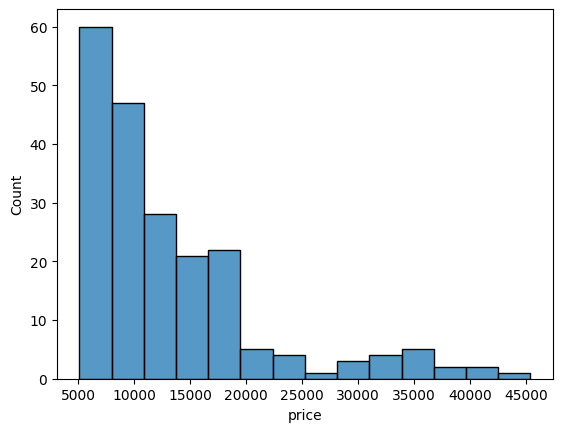

In [11]:
# Cek informasi dasar data
print(df.info())
print(df.describe())

# Contoh visualisasi EDA (Ganti dengan visualisasi aslimu ya Wak)
sns.histplot(df['price'])
plt.show()

# 5. Data Preprocessing

In [12]:
# 1. Hapus duplikat / missing values (jika ada)
df = df.drop_duplicates()

# 2. Pisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['price']) # Gantilah 'price' sesuai kolom target aslimu
y = df['price']

# 3. Encoding Fitur Kategorikal (jika ada)
X = pd.get_dummies(X, drop_first=True)

# 4. Split Dataset menjadi Train dan Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Normalisasi / Standarisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)